In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
iterative = pd.read_csv('pathfinding_iteratively_benchmark.csv')
iterative['method'] = 'ours: iterative'
networkit = pd.read_csv('pathfinding_networkit_benchmark.csv')
networkit['method'] = 'networkit'
networkx = pd.read_csv('pathfinding_networkx_benchmark.csv')
networkx['method'] = 'networkx'
oflength = pd.read_csv('pathfinding_oflength_benchmark.csv')
oflength['method'] = 'ours: oflength'
oflength

,source_type,dn_type,path_length,total_time,source_count,target_count,n_connections,method
0,JO-EDP,DNa15,2,0.336788,12,2,7,ours: oflength
1,JO-EDP,DNpe043,2,0.111371,12,2,0,ours: oflength
2,JO-EDP,DNge071,2,0.356689,12,16,15,ours: oflength
3,JO-EDP,DNge055,2,0.097453,12,2,0,ours: oflength
4,JO-EDP,DNp46,2,0.217206,12,2,2,ours: oflength
...,...,...,...,...,...,...,...,...
95,ORN_DM3,DNa15,5,2.964177,61,2,544455,ours: oflength
96,ORN_DM3,DNpe043,5,3.306434,61,2,1288090,ours: oflength
97,ORN_DM3,DNge071,5,2.372616,61,16,89148,ours: oflength
98,ORN_DM3,DNge055,5,2.893413,61,2,291004,ours: oflength


In [3]:
out = pd.concat([iterative, networkit, networkx, oflength])

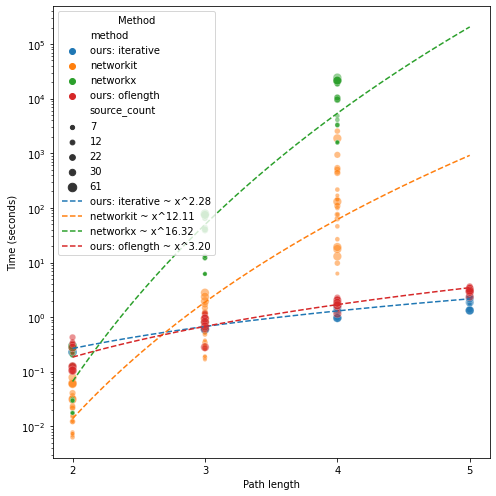

In [5]:
# scatter + per-method power-law fit lines (y = c * x^b)
# --- scatter
methods = out["method"].unique().tolist()
palette = sns.color_palette("tab10", n_colors=len(methods))
color_map = dict(zip(methods, palette))
plt.figure(figsize=(7,7))
ax = sns.scatterplot(
    data=out, x="path_length", y="total_time", size='source_count',
    hue="method", palette=color_map, alpha=0.5
)

# --- fitted lines
for m in methods:
    sub = out[out["method"] == m]
    x = sub["path_length"].to_numpy(float)
    y = sub["total_time"].to_numpy(float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        continue

    # power-law fit via log–log
    b, logc = np.polyfit(np.log(x), np.log(y), 1)
    c = np.exp(logc)

    x_line = np.linspace(x.min(), 5, 200)
    y_line = c * x_line**b
    plt.plot(x_line, y_line, "--", color=color_map[m], label=f"{m} ~ x^{b:.2f}")

# --- axes and ticks
plt.yscale("log")
xticks = np.unique(out["path_length"].astype(int))
plt.xticks(ticks=xticks)
plt.xlabel("Path length")
plt.ylabel("Time (seconds)")
plt.legend(title="Method")
plt.tight_layout()
plt.savefig("pathfinding_benchmark.png", )
plt.savefig("pathfinding_benchmark.pdf", )
